# Pix2Pix — Paired Image-to-Image Translation

This notebook implements **Pix2Pix** (Isola et al., 2017), following Module 15.

Until now we have been generating images **from noise** (with optional class conditioning):

$$G(z) \rightarrow x$$

Pix2Pix drops the noise as the primary input and replaces it with an **input image**:

$$G(x) \rightarrow y$$

where $x$ comes from one visual domain (edges, sketches, grayscale photos, maps) and $y$ is the matching image in another domain. The Generator's job becomes *transform* rather than *invent*.

Three architectural and training tricks distinguish Pix2Pix:

1. **U-Net Generator** with skip connections, so spatial detail from $x$ can flow directly to the output.
2. **PatchGAN Discriminator** that judges local patches of the $(x, y)$ pair, not the whole image as a single scalar.
3. **Hybrid loss**: adversarial BCE on the patch map **plus** an L1 distance to the ground-truth target, weighted by $\lambda_{L1} = 100$.

We pair MNIST digits with their edge maps (computed via a Sobel filter). The task: given an edge map, generate the filled digit.

## Implementation Plan

- **Dataset**: MNIST. For each digit we generate an edge map on the fly using a fixed Sobel kernel. The pair is $(x, y) = (\text{edges}, \text{digit})$.
- **Generator**: U-Net with 5 encoder blocks, 4 decoder blocks, and 4 skip connections. Each block is two convs with BatchNorm + LeakyReLU.
- **Discriminator**: PatchGAN. Five conv layers. Input is the concatenation of $x$ and $y$ along the channel axis (so `in_channels = 2`). Output is an $8 \times 8$ logit map where each cell judges a local patch of the pair.
- **Loss**: `BCEWithLogitsLoss` on the patch map + `L1Loss` between $G(x)$ and $y$ scaled by $\lambda_{L1} = 100$.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt
import numpy as np
import os

torch.manual_seed(42)
np.random.seed(42)

## 1. Setup and Hyperparameters

U-Nets are bigger than DCGAN generators, so we drop `batch_size` to 16. Two new pieces:

- `lambda_l1 = 100` (paper default) — the weight of the reconstruction term in the Generator loss.
- `in_channels_d = 2` — the PatchGAN's first conv sees both the input edges and the target digit stacked along channels.

In [2]:
img_channels = 1
img_size     = 64
features     = 64
batch_size   = 16
lr           = 2e-4
betas        = (0.5, 0.999)
epochs       = 25
lambda_l1    = 100

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

os.makedirs('samples_Pix2Pix', exist_ok=True)

Using device: cuda


## 2. Data — MNIST and a Sobel Edge Pair

The dataset is **paired** in the Pix2Pix sense:

- $y$ is the MNIST digit (after `Resize(64)` and normalization to $[-1, +1]$).
- $x$ is a Sobel-edge magnitude map of the same digit, also normalized to $[-1, +1]$.

We compute edges with two fixed $3 \times 3$ Sobel kernels (one per axis). The edge magnitude $\sqrt{G_x^2 + G_y^2}$ is then rescaled per-image into $[-1, +1]$ so the Generator's `Tanh` output range matches.

In [3]:
transform = transforms.Compose([
    transforms.Resize(img_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),    # (0,1) -> (-1,1)
])

dataloader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)


def sobel_edges(x):
    """
    Compute per-image Sobel edge magnitude for a (B, 1, H, W) tensor.
    Returns a (B, 1, H, W) tensor in [-1, 1] per image.
    """
    device = x.device
    kx = torch.tensor([[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]], device=device).view(1, 1, 3, 3)
    ky = torch.tensor([[-1., -2., -1.], [0., 0., 0.], [1., 2., 1.]], device=device).view(1, 1, 3, 3)
    gx = F.conv2d(x, kx, padding=1)
    gy = F.conv2d(x, ky, padding=1)
    mag = torch.sqrt(gx ** 2 + gy ** 2 + 1e-8)
    mag = mag / (mag.amax(dim=(2, 3), keepdim=True) + 1e-8)
    mag = mag * 2.0 - 1.0
    return mag

100%|██████████| 9.91M/9.91M [00:00<00:00, 59.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.71MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.9MB/s]


## 3. Weight Initialization

Same DCGAN-style init.

In [4]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

## 4. The Generator — U-Net with Skip Connections

Spatial flow:

```
      Encoder                Decoder (with skips)
                          
  e1: 64x64,  f           f  <---- concat e1 ----  d1: 64x64
       ↓ pool              ↑ up
  e2: 32x32,  2f         2f  <---- concat e2 ----  d2: 32x32
       ↓ pool              ↑ up
  e3: 16x16,  4f         4f  <---- concat e3 ----  d3: 16x16
       ↓ pool              ↑ up
  e4:  8x8,   8f         8f  <---- concat e4 ----  d4:  8x8
       ↓ pool              ↑ up
  e5:  4x4,   8f  (bottleneck)
```

Each `enc_i` and `dec_i` is a *double conv* block (Conv-BN-LeakyReLU twice). Each skip connection **concatenates** the encoder feature map with the corresponding decoder feature map along the channel axis. That is what preserves spatial detail across the bottleneck — the alternative (sending everything through the bottleneck) loses low-level structure.

The Generator outputs through `Tanh` so its range matches the input data range $[-1, +1]$.

In [5]:
class UNetGenerator(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=64):
        super().__init__()

        def block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.LeakyReLU(0.2, inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.LeakyReLU(0.2, inplace=True),
            )

        # Encoder
        self.enc1 = block(in_channels, features)        # 64x64,  f
        self.enc2 = block(features,     features * 2)   # 32x32,  2f
        self.enc3 = block(features * 2, features * 4)   # 16x16,  4f
        self.enc4 = block(features * 4, features * 8)   #  8x8,   8f
        self.enc5 = block(features * 8, features * 8)   #  4x4,   8f  (bottleneck)

        self.pool = nn.MaxPool2d(2)

        # Decoder (with skip connections via concatenation)
        self.up4 = nn.ConvTranspose2d(features * 8, features * 8, 2, 2)  # 4 -> 8
        self.dec4 = block(features * 16, features * 8)

        self.up3 = nn.ConvTranspose2d(features * 8, features * 4, 2, 2)  # 8 -> 16
        self.dec3 = block(features * 8, features * 4)

        self.up2 = nn.ConvTranspose2d(features * 4, features * 2, 2, 2)  # 16 -> 32
        self.dec2 = block(features * 4, features * 2)

        self.up1 = nn.ConvTranspose2d(features * 2, features,     2, 2)  # 32 -> 64
        self.dec1 = block(features * 2, features)

        self.final = nn.Conv2d(features, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder path with saved feature maps for skip connections
        e1 = self.enc1(x)                  # 64x64, f
        e2 = self.enc2(self.pool(e1))      # 32x32, 2f
        e3 = self.enc3(self.pool(e2))      # 16x16, 4f
        e4 = self.enc4(self.pool(e3))      #  8x8, 8f
        e5 = self.enc5(self.pool(e4))      #  4x4, 8f  (bottleneck)

        # Decoder path with skip connections (concatenation)
        d4 = self.up4(e5)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return torch.tanh(self.final(d1))

## 5. The Discriminator — PatchGAN

Two key departures from earlier DCGAN-style discriminators:

1. **Input is two channels, not one.** We concatenate the source image $x$ and the target image $y$ (real or generated) along the channel axis. The PatchGAN judges the *pair*, not just the target alone. That is what makes it a conditional discriminator $D(x, y)$.
2. **Output is a logit map, not a scalar.** Each cell of the output map corresponds to a local receptive field of the input pair. The BCE loss is averaged over all cells, so each patch is being judged independently.

Spatial flow for $64 \times 64$ input:

```
64 -> 32 -> 16 -> 8 -> 8 -> 8
 2   64    128   256   512   1
```

The output is an $8 \times 8$ map of patch-level real/fake predictions.

In [6]:
class PatchDiscriminator(nn.Module):
    def __init__(self, in_channels=2, features=64):
        super().__init__()
        self.net = nn.Sequential(
            # 64 -> 32, NO BatchNorm in the first block
            nn.Conv2d(in_channels, features, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 -> 16
            nn.Conv2d(features, features * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features * 2),
            nn.LeakyReLU(0.2, inplace=True),

            # 16 -> 8
            nn.Conv2d(features * 2, features * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features * 4),
            nn.LeakyReLU(0.2, inplace=True),

            # 8 -> 8 (stride 1, kernel 3, preserves spatial size)
            nn.Conv2d(features * 4, features * 8, 3, 1, 1, bias=False),
            nn.BatchNorm2d(features * 8),
            nn.LeakyReLU(0.2, inplace=True),

            # final 1-channel logit map (8x8)
            nn.Conv2d(features * 8, 1, 3, 1, 1, bias=False),
        )

    def forward(self, x, y):
        # x: input edges, y: target (real or generated)
        xy = torch.cat([x, y], dim=1)
        return self.net(xy)

## 6. Models, Optimizers, and Two Loss Functions

Two losses in play:

- `bce` — `BCEWithLogitsLoss` for the adversarial term (matches each cell of the PatchGAN's logit map against the appropriate target).
- `l1` — `L1Loss` for the reconstruction term.

The Generator's loss is a sum:

$$L_G = L_{adv} + \lambda_{L1} \cdot L_{L1}$$

The Discriminator's loss is just the adversarial term.

In [7]:
G = UNetGenerator(in_channels=img_channels, out_channels=img_channels, features=features).to(device)
D = PatchDiscriminator(in_channels=img_channels * 2, features=features).to(device)

G.apply(weights_init)
D.apply(weights_init)

optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=betas)
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=betas)

bce = nn.BCEWithLogitsLoss()
l1  = nn.L1Loss()

print(f'G params: {sum(p.numel() for p in G.parameters()):,}')
print(f'D params: {sum(p.numel() for p in D.parameters()):,}')
print()
print(G)
print()
print(D)

G params: 20,548,673
D params: 1,843,456

UNetGenerator(
  (enc1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_

## 7. Fixed Test Batch for Visualization
Pix2Pix is **paired** — the visualization should show the same fixed examples every epoch so we can watch the Generator learn the mapping. We sample a small fixed batch once and reuse it for visualization.

In [8]:
fixed_batch = next(iter(dataloader))
fixed_y, _  = fixed_batch
fixed_y     = fixed_y.to(device)[:8]
fixed_x     = sobel_edges(fixed_y)

print('fixed_x (edges):', tuple(fixed_x.shape))
print('fixed_y (digits):', tuple(fixed_y.shape))

fixed_x (edges): (8, 1, 64, 64)
fixed_y (digits): (8, 1, 64, 64)


## 8. The Training Loop

Three losses per iteration, two phases, same alternating pattern as DCGAN/cGAN.

**Phase A — Train D**

1. Real pair: $D(x, y)$, target $1$ everywhere on the $8 \times 8$ logit map.
2. Fake pair (detached): $D(x, G(x))$, target $0$ everywhere on the logit map.
3. BCE on both, sum, backprop into D.

**Phase B — Train G**

1. Generate $\hat{y} = G(x)$ (no detach).
2. Adversarial BCE on $D(x, \hat{y})$ against target $1$ — fool the patch discriminator.
3. L1 between $\hat{y}$ and $y$, scaled by $\lambda_{L1}$ — keep the output close to the ground truth.
4. Sum, backprop through D into G, update only G.

The L1 term is what makes Pix2Pix *paired* image translation rather than just conditional generation. Without it, the Generator would still produce realistic-looking outputs — they just wouldn't match the input structure.

In [9]:
losses_d     = []
losses_g     = []
losses_g_adv = []
losses_g_l1  = []

G.train()
D.train()

for epoch in range(epochs):
    sum_d     = 0.0
    sum_g     = 0.0
    sum_adv   = 0.0
    sum_l1    = 0.0
    n_batches = 0

    for real_y, _ in dataloader:
        real_y = real_y.to(device)
        real_x = sobel_edges(real_y)
        b = real_y.size(0)

        # Patch map targets: shape matches D(x, y) output (B, 1, 8, 8)
        valid = torch.ones(b, 1, 8, 8, device=device)
        fake_t = torch.zeros(b, 1, 8, 8, device=device)

        # -----------------
        # Phase A: Train D
        # -----------------
        optimizer_D.zero_grad()

        # Real pair: D(x, y) -> 1
        real_pred = D(real_x, real_y)
        d_real_loss = bce(real_pred, valid)

        # Fake pair (detached): D(x, G(x)) -> 0
        with torch.no_grad():
            fake_y = G(real_x)
        fake_pred = D(real_x, fake_y)
        d_fake_loss = bce(fake_pred, fake_t)

        d_loss = (d_real_loss + d_fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()

        # -----------------
        # Phase B: Train G
        # -----------------
        optimizer_G.zero_grad()

        fake_y = G(real_x)                    # NO detach
        fake_pred = D(real_x, fake_y)
        g_adv = bce(fake_pred, valid)         # want patch map to read 1
        g_l1  = l1(fake_y, real_y) * lambda_l1
        g_loss = g_adv + g_l1

        g_loss.backward()
        optimizer_G.step()

        sum_d   += d_loss.item()
        sum_g   += g_loss.item()
        sum_adv += g_adv.item()
        sum_l1  += g_l1.item()
        n_batches += 1

    avg_d   = sum_d   / n_batches
    avg_g   = sum_g   / n_batches
    avg_adv = sum_adv / n_batches
    avg_l1  = sum_l1  / n_batches
    losses_d.append(avg_d)
    losses_g.append(avg_g)
    losses_g_adv.append(avg_adv)
    losses_g_l1.append(avg_l1)

    print(
        f"Epoch [{epoch+1}/{epochs}]  "
        f"D: {avg_d:.3f}  "
        f"G: {avg_g:.3f}  (adv {avg_adv:.3f}, L1 {avg_l1:.3f})"
    )

    # Save a fixed input | generated | ground-truth grid every epoch
    G.eval()
    with torch.no_grad():
        gen_y = G(fixed_x).detach().cpu()
    G.train()

    comparison = torch.cat([fixed_x.cpu(), gen_y, fixed_y.cpu()], dim=0)
    save_image(
        comparison,
        f"samples_Pix2Pix/epoch_{epoch+1:02d}.png",
        nrow=8,
        normalize=True,
    )

print('Training done.')

Epoch [1/25]  D: 0.597  G: 5.759  (adv 1.239, L1 4.520)
Epoch [2/25]  D: 0.692  G: 1.391  (adv 0.703, L1 0.688)
Epoch [3/25]  D: 0.693  G: 1.209  (adv 0.699, L1 0.510)
Epoch [4/25]  D: 0.693  G: 1.127  (adv 0.698, L1 0.429)
Epoch [5/25]  D: 0.693  G: 1.079  (adv 0.697, L1 0.382)
Epoch [6/25]  D: 0.693  G: 1.033  (adv 0.696, L1 0.337)
Epoch [7/25]  D: 0.693  G: 1.007  (adv 0.698, L1 0.310)
Epoch [8/25]  D: 0.690  G: 1.001  (adv 0.713, L1 0.288)
Epoch [9/25]  D: 0.688  G: 0.988  (adv 0.718, L1 0.270)
Epoch [10/25]  D: 0.688  G: 0.987  (adv 0.724, L1 0.263)
Epoch [11/25]  D: 0.689  G: 0.965  (adv 0.720, L1 0.245)
Epoch [12/25]  D: 0.693  G: 0.927  (adv 0.694, L1 0.233)
Epoch [13/25]  D: 0.693  G: 0.920  (adv 0.695, L1 0.225)
Epoch [14/25]  D: 0.693  G: 0.910  (adv 0.695, L1 0.215)
Epoch [15/25]  D: 0.693  G: 0.909  (adv 0.699, L1 0.210)
Epoch [16/25]  D: 0.691  G: 0.914  (adv 0.708, L1 0.206)
Epoch [17/25]  D: 0.690  G: 0.911  (adv 0.710, L1 0.202)
Epoch [18/25]  D: 0.655  G: 1.114  (adv 

## 9. Paired Visualization — Input Edges | Generated Digit | Ground Truth

Three rows stacked vertically:

1. The input edge map $x$
2. What the Generator produced $\hat{y} = G(x)$
3. The actual target digit $y$

If the Generator has learned, rows 2 and 3 should look similar; row 1 should look like an edge sketch of both.

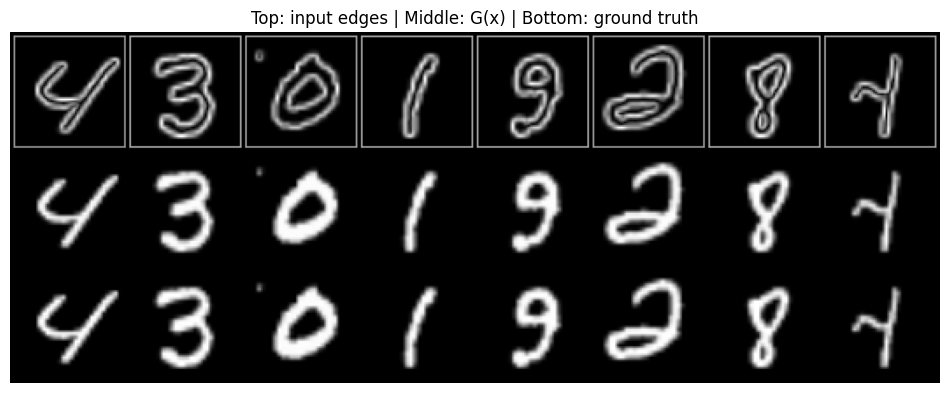

In [10]:
G.eval()
with torch.no_grad():
    gen_y = G(fixed_x).cpu()

comparison = torch.cat([fixed_x.cpu(), gen_y, fixed_y.cpu()], dim=0)
grid = make_grid(comparison, nrow=8, normalize=True)
plt.figure(figsize=(12, 5))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
plt.axis('off')
plt.title('Top: input edges | Middle: G(x) | Bottom: ground truth')
plt.show()

## 10. Training Progression

Each saved PNG is the full input | generated | ground-truth stack for the fixed test batch. Watch row 2 (the generated row) sharpen into a recognizable digit as training proceeds.

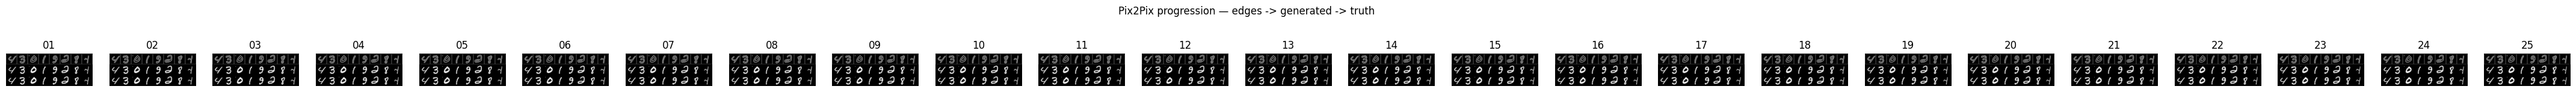

In [11]:
from PIL import Image
import glob

paths = sorted(glob.glob('samples_Pix2Pix/epoch_*.png'))
if paths:
    fig, axes = plt.subplots(1, len(paths), figsize=(2.2 * len(paths), 2.2))
    if len(paths) == 1:
        axes = [axes]
    for ax, p in zip(axes, paths):
        ax.imshow(np.array(Image.open(p)).squeeze(), cmap='gray')
        ax.set_title(p.split('_')[-1].split('.')[0])
        ax.axis('off')
    plt.suptitle('Pix2Pix progression — edges -> generated -> truth')
    plt.show()
else:
    print('No sample grids found. Run the training cell first.')

## 11. Loss Curves

Three Generator-side curves worth tracking:

- **G adversarial** should hover near a small positive number; if it collapses toward 0 the PatchGAN is overpowering the Generator.
- **G L1** is the dominant term ($\lambda_{L1} = 100$ magnifies it). It should fall steadily as the Generator learns the per-pixel mapping.
- **D loss** should stay around the $\ln 2 \approx 0.69$ equilibrium the PatchGAN settles into when both real and fake pairs look equally realistic.

Note: G-L1 typically dwarfs G-adv because of the $\lambda$ scaling. The plot below shows them on the same axis for completeness; the Generator's *effective* improvement is better read off the L1 curve.

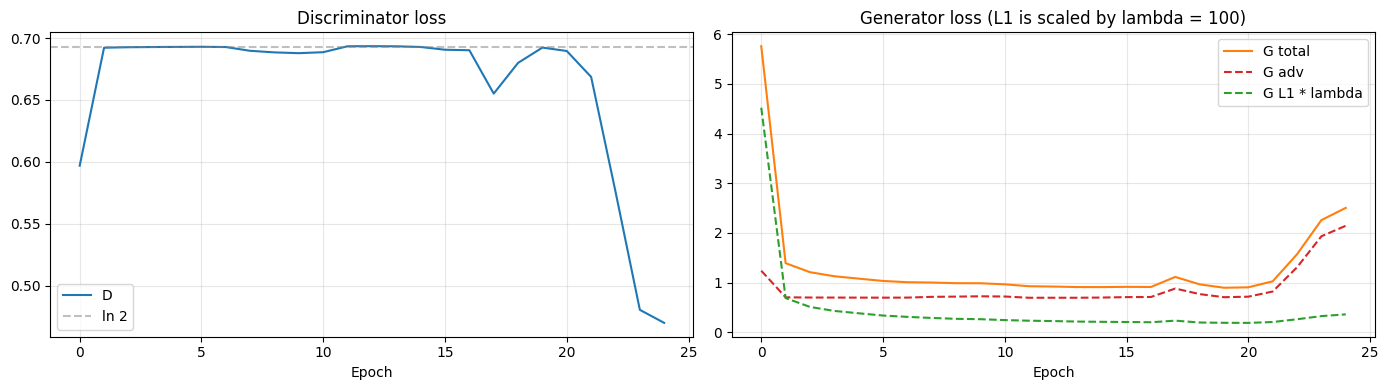

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(losses_d, label='D', color='tab:blue')
axes[0].axhline(np.log(2), color='gray', linestyle='--', alpha=0.5, label='ln 2')
axes[0].set_xlabel('Epoch')
axes[0].set_title('Discriminator loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(losses_g,     label='G total', color='tab:orange')
axes[1].plot(losses_g_adv, label='G adv',   color='tab:red',    linestyle='--')
axes[1].plot(losses_g_l1,  label='G L1 * lambda', color='tab:green', linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_title('Generator loss (L1 is scaled by lambda = 100)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Recap — How Pix2Pix Differs From cGAN / ACGAN

| Concern | cGAN / ACGAN | Pix2Pix |
|---|---|---|
| Generator input | $z$ (with optional class) | **image $x$ from another domain** |
| Generator output | $x_\text{generated}$ | **transformed image** matching paired target |
| Discriminator input | $x$ (with optional class) | **$(x, y)$ pair** — source concatenated with target |
| Discriminator output | single real/fake logit | **logit MAP** — one number per local patch |
| Loss | adversarial BCE | **adversarial BCE + L1** reconstruction |
| Architecture | DCGAN conv stack | **U-Net with skip connections** |
| Pairing | none | **paired data required** |
| Distribution modeled | $p(x)$ or $p(x \mid c)$ | $p(y \mid x)$ for paired $(x, y)$ |

**What changed and why:**

- **U-Net Generator.** The encoder-decoder with skip connections preserves spatial detail that pure downsampling-then-upsampling would destroy. Without skips, edges and small structures in the input get smeared across the bottleneck.
- **PatchGAN Discriminator.** A scalar real/fake logit focuses on global realism. A patch map focuses on local realism. For paired translation, local realism is what we actually care about — the global structure is already supplied by the input $x$. Each output cell judges a local receptive field of the $(x, y)$ pair, so the loss is essentially a mean of many local judgments.
- **L1 reconstruction term.** This is what binds the output to the *specific* paired target. Drop $\lambda_{L1}$ and the Generator still produces a realistic digit — it just won't necessarily match the input edges. The paper uses $\lambda_{L1} = 100$ because GAN loss has much smaller magnitude than the L1 distance.

**Common implementation pitfalls** — quick reference:

- **Concatenate along channels, not spatially.** The PatchGAN's first conv must see both $x$ and $y$ stacked along the channel axis. `torch.cat([x, y], dim=1)`. Concatenating along the spatial axis would silently produce wrong-shaped inputs.
- **Patch map target shape.** The target for `BCEWithLogitsLoss` must match the patch logit map shape `(B, 1, H, W)`. Don't pass a `(B, 1)` target — that would broadcast incorrectly.
- **Skip connection channels must match the decoder after concat.** When you concatenate `enc_i` (say $8f$ channels) with the upsampled decoder feature (also $8f$ channels), the input to the next conv block is $16f$. The `_block` definition takes that doubling into account — change one without the other and dimensions won't line up.
- **`detach()` on fakes during the D phase.** Otherwise gradients sneak into $G$.
- **Bigger model, smaller batch.** U-Net is much heavier than DCGAN. If you run out of memory, drop `batch_size` before `features`.
- **L1 loss needs the $\lambda$ weight.** Without it the Generator can win on L1 cheaply and ignore the discriminator, producing blurry-but-close outputs. With it, the adversarial loss has comparable influence.
- **Paired data is non-negotiable.** Pix2Pix cannot invent correspondences — that's exactly the problem CycleGAN tackles next.

**Next in the series** (Module 16): CycleGAN. Pix2Pix's biggest limitation is the paired-data requirement. CycleGAN drops it by training *two* Generators ($G: A \to B$ and $F: B \to A$) and a *cycle consistency* constraint $F(G(x)) \approx x$ — so the network can learn $A \leftrightarrow B$ from unpaired collections.

In [13]:
import zipfile
import os
from google.colab import files

# Define the directory to be zipped
directory_to_zip = 'samples_Pix2Pix'
zip_file_name = f'{directory_to_zip}.zip'

# Create a ZipFile object
with zipfile.ZipFile(zip_file_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files_in_dir in os.walk(directory_to_zip):
        for file in files_in_dir:
            file_path = os.path.join(root, file)
            # Add file to zip, preserving directory structure
            zipf.write(file_path, os.path.relpath(file_path, directory_to_zip))

print(f"'{directory_to_zip}' has been successfully zipped into '{zip_file_name}'")

# Offer the zip file for download
files.download(zip_file_name)

'samples_Pix2Pix' has been successfully zipped into 'samples_Pix2Pix.zip'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>